<a href="https://colab.research.google.com/github/anderson-perez/IAC/blob/main/A0%20-%20Fundamentos%20Matem%C3%A1ticos/Resumo_C%C3%A1lculo.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Inteligência Artificial e Computacional

## Segunda Parte da Disciplina

# Informações:

- Prof. Anderson Luiz Fernandes Perez
- Contato: anderson.perez@ufsc.br | anderson.lfp@gmail.com
- Os materiais da disciplina estarão disponíveis no github (https://github.com/anderson-perez/IAC.git)

# Cálculo para Inteligência Artificial

Este notebook apresenta conceitos fundamentais de **Cálculo Diferencial** usados em Inteligência Artificial e Aprendizado de Máquina. O objetivo é mostrar como o cálculo aparece naturalmente quando é necessário ajustar parâmetros de um modelo para minimizar erros.

# Funções

Uma função associa uma entrada a uma saída.

Por exemplo:

$$
f(x) = x^2
$$

Se $x = 3$, então:

$$
f(3) = 3^2 = 9
$$

Em aprendizado de máquina, modelos também podem ser vistos como funções.

Exemplo:

$$
\hat{y} = f(x)
$$

onde:

- $x$ é a entrada;
- $\hat{y}$ é a predição do modelo.

## Visualização Gráfica de uma Função

Vamos começar com:

$$
f(x) = x^2
$$

In [39]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

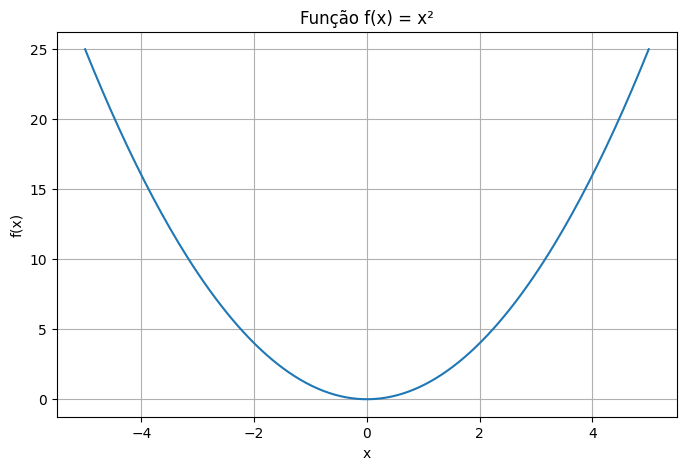

In [3]:
def f(x):
    return x**2

x = np.linspace(-5, 5, 200)
y = f(x)

plt.figure(figsize=(8, 5))
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Função f(x) = x²")
plt.grid(True)
plt.show()

# Derivadas

A derivada mede a taxa de variação de uma função.

De forma intuitiva:

- se a derivada é positiva, a função está crescendo;
- se a derivada é negativa, a função está decrescendo;
- se a derivada é zero, pode haver um ponto de mínimo, máximo ou sela.

A derivada de uma função $f(x)$ é definida como:

$$
f'(x) =
\lim_{h \to 0}
\frac{f(x+h) - f(x)}{h}
$$

Essa expressão mede a inclinação da reta tangente à curva no ponto $x$.

## Derivada de uma Função Simples

Para:

$$
f(x) = x^2
$$

a derivada é:

$$
f'(x) = 2x
$$

Isso significa que a inclinação da curva depende do valor de $x$.

In [4]:
def df(x):
    return 2*x

pontos = np.array([-3, -1, 0, 1, 3])

for p in pontos:
    print(f"x = {p: .1f}, f(x) = {f(p): .1f}, f'(x) = {df(p): .1f}")

x = -3.0, f(x) =  9.0, f'(x) = -6.0
x = -1.0, f(x) =  1.0, f'(x) = -2.0
x =  0.0, f(x) =  0.0, f'(x) =  0.0
x =  1.0, f(x) =  1.0, f'(x) =  2.0
x =  3.0, f(x) =  9.0, f'(x) =  6.0


## A Reta Tangente

A reta tangente em um ponto $x_0$ pode ser escrita como:

$$
y = f(x_0) + f'(x_0)(x - x_0)
$$

Vamos visualizar a tangente de $f(x)=x^2$ no ponto $x_0=2$.

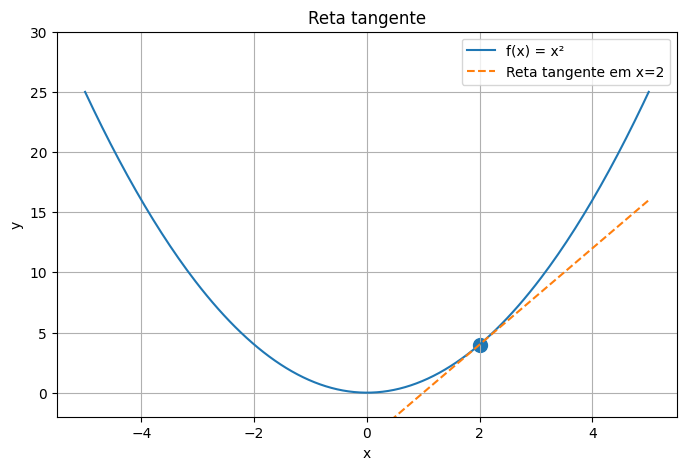

In [5]:
x0 = 2
y0 = f(x0)
incl = df(x0)

reta_tangente = y0 + incl * (x - x0)

plt.figure(figsize=(8, 5))
plt.plot(x, y, label="f(x) = x²")
plt.plot(x, reta_tangente, "--", label="Reta tangente em x=2")
plt.scatter([x0], [y0], s=100)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Reta tangente")
plt.legend()
plt.grid(True)
plt.ylim(-2, 30)
plt.show()

## Aproximação Numérica de uma Derivada

Também podemos aproximar a derivada numericamente usando:

$$
f'(x) \approx \frac{f(x+h) - f(x)}{h}
$$

Quanto menor for $h$, melhor tende a ser a aproximação, até certo limite numérico.

In [6]:
def derivada_numerica(funcao, x, h=1e-5):
    return (funcao(x + h) - funcao(x)) / h

for p in pontos:
    print(f"x = {p: .1f}, derivada exata = {df(p): .4f}, derivada numérica = {derivada_numerica(f, p): .4f}")

x = -3.0, derivada exata = -6.0000, derivada numérica = -6.0000
x = -1.0, derivada exata = -2.0000, derivada numérica = -2.0000
x =  0.0, derivada exata =  0.0000, derivada numérica =  0.0000
x =  1.0, derivada exata =  2.0000, derivada numérica =  2.0000
x =  3.0, derivada exata =  6.0000, derivada numérica =  6.0000


## Derivadas Simbólicas com SymPy

A biblioteca `sympy` permite calcular derivadas simbolicamente.

In [40]:
import sympy as sp

In [7]:
x_sym = sp.Symbol("x")

f_sym = x_sym**2
df_sym = sp.diff(f_sym, x_sym)

print("f(x) =", f_sym)
print("f'(x) =", df_sym)

f(x) = x**2
f'(x) = 2*x


## Derivadas Mais Comuns


| Função | Derivada |
|---|---|
| $f(x)=x^n$ | $f'(x)=nx^{n-1}$ |
| $f(x)=e^x$ | $f'(x)=e^x$ |
| $f(x)=\ln(x)$ | $f'(x)=1/x$ |
| $f(x)=\sin(x)$ | $f'(x)=\cos(x)$ |
| $f(x)=\cos(x)$ | $f'(x)=-\sin(x)$ |

A função exponencial e o logaritmo aparecem muito em funções de perda, modelos probabilísticos e redes neurais.

In [8]:
funcoes = [
    x_sym**3,
    sp.exp(x_sym),
    sp.log(x_sym),
    sp.sin(x_sym),
    sp.cos(x_sym)
]

for func in funcoes:
    print("f(x) =", func)
    print("f'(x) =", sp.diff(func, x_sym))
    print()

f(x) = x**3
f'(x) = 3*x**2

f(x) = exp(x)
f'(x) = exp(x)

f(x) = log(x)
f'(x) = 1/x

f(x) = sin(x)
f'(x) = cos(x)

f(x) = cos(x)
f'(x) = -sin(x)



# Derivadas e Otimização

Em IA, muitas vezes é necessário minimizar uma função de erro ou perda.

Exemplo:

$$
L(w) = (w - 3)^2
$$

Essa função tem mínimo em $w=3$.

A derivada é:

$$
L'(w) = 2(w - 3)
$$

Se a derivada é positiva, devemos diminuir $w$.

Se a derivada é negativa, devemos aumentar $w$.

## Visualização de uma Função de Perda

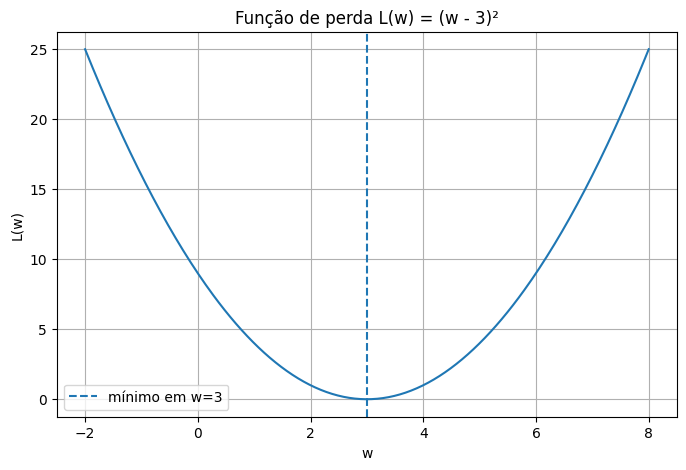

In [9]:
def L(w):
    return (w - 3)**2

def dL(w):
    return 2*(w - 3)

w = np.linspace(-2, 8, 300)

plt.figure(figsize=(8, 5))
plt.plot(w, L(w))
plt.axvline(3, linestyle="--", label="mínimo em w=3")
plt.xlabel("w")
plt.ylabel("L(w)")
plt.title("Função de perda L(w) = (w - 3)²")
plt.legend()
plt.grid(True)
plt.show()

## Descida do Gradiente em uma Dimensão

A descida do gradiente atualiza o parâmetro na direção oposta à derivada:

$$
w \leftarrow w - \alpha L'(w)
$$

onde:

- $w$ é o parâmetro;
- $\alpha$ é a taxa de aprendizado;
- $L'(w)$ é a derivada da função de perda.

A taxa de aprendizado controla o tamanho do passo.

In [10]:
w_atual = -1.0
alpha = 0.1
historico_w = [w_atual]
historico_L = [L(w_atual)]

for epoca in range(30):
    grad = dL(w_atual)
    w_atual = w_atual - alpha * grad

    historico_w.append(w_atual)
    historico_L.append(L(w_atual))

print("w final:", w_atual)
print("L(w) final:", L(w_atual))

w final: 2.995048239842858
L(w) final: 2.451992865385725e-05


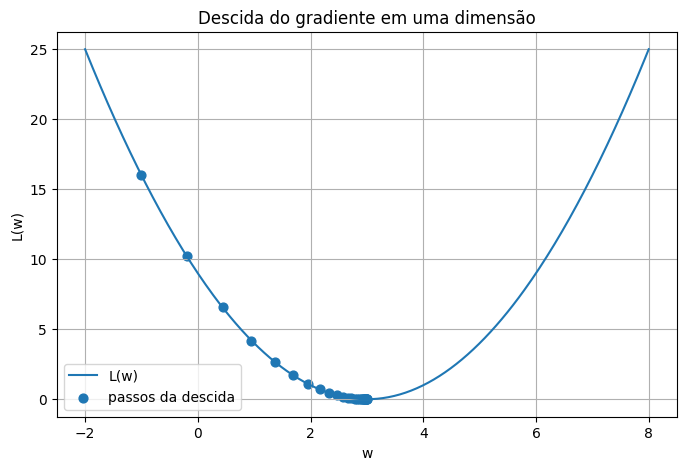

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(w, L(w), label="L(w)")
plt.scatter(historico_w, historico_L, s=40, label="passos da descida")
plt.xlabel("w")
plt.ylabel("L(w)")
plt.title("Descida do gradiente em uma dimensão")
plt.legend()
plt.grid(True)
plt.show()

## Efeito da Taxa de Aprendizado

A taxa de aprendizado é um hiperparâmetro importante.

- Se for muito pequena, o treinamento pode ser lento.
- Se for muito grande, o algoritmo pode oscilar ou divergir.

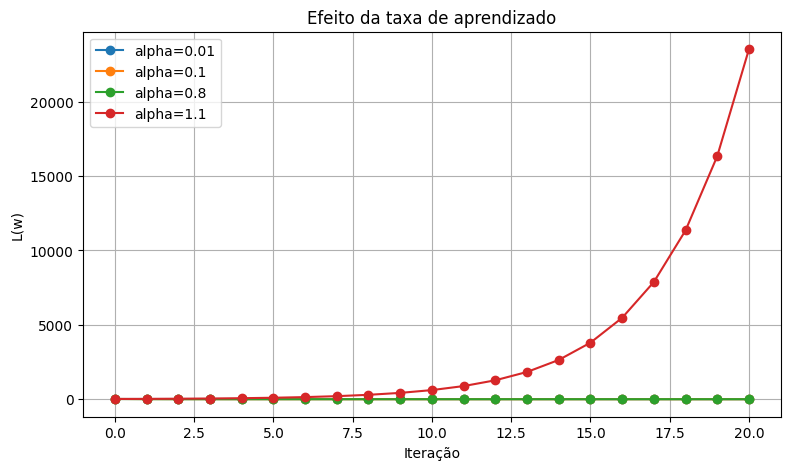

In [12]:
def executar_descida(alpha, w_inicial=-1.0, passos=20):
    w_atual = w_inicial
    historico = [w_atual]

    for _ in range(passos):
        w_atual = w_atual - alpha * dL(w_atual)
        historico.append(w_atual)

    return np.array(historico)

taxas = [0.01, 0.1, 0.8, 1.1]

plt.figure(figsize=(9, 5))

for taxa in taxas:
    hist = executar_descida(taxa)
    perdas = L(hist)
    plt.plot(perdas, marker="o", label=f"alpha={taxa}")

plt.xlabel("Iteração")
plt.ylabel("L(w)")
plt.title("Efeito da taxa de aprendizado")
plt.legend()
plt.grid(True)
plt.show()

# Funções de Várias Variáveis

Um modelo de IA normalmente possue muitos parâmetros.

Por exemplo, um modelo linear simples pode ter:

$$
\hat{y} = wx + b
$$

Nesse caso, a função de perda depende de dois parâmetros:

$$
L(w,b)
$$

Quando uma função depende de várias variáveis, é necessário utilizar **derivadas parciais**.

## Derivadas Parciais

A derivada parcial mede a taxa de variação de uma função em relação a uma variável, mantendo as demais constantes.

Exemplo:

$$
f(x,y) = x^2 + y^2
$$

Derivada parcial em relação a $x$:

$$
\frac{\partial f}{\partial x} = 2x
$$

Derivada parcial em relação a $y$:

$$
\frac{\partial f}{\partial y} = 2y
$$

In [13]:
x_sym, y_sym = sp.symbols("x y")

f_xy = x_sym**2 + y_sym**2

df_dx = sp.diff(f_xy, x_sym)
df_dy = sp.diff(f_xy, y_sym)

print("f(x,y) =", f_xy)
print("∂f/∂x =", df_dx)
print("∂f/∂y =", df_dy)

f(x,y) = x**2 + y**2
∂f/∂x = 2*x
∂f/∂y = 2*y


## Gradiente

O gradiente é o vetor formado pelas derivadas parciais.

Para uma função $f(x,y)$:

$$
\nabla f(x,y)
=
\begin{bmatrix}
\frac{\partial f}{\partial x} \\
\frac{\partial f}{\partial y}
\end{bmatrix}
$$

Para:

$$
f(x,y) = x^2 + y^2
$$

temos:

$$
\nabla f(x,y)
=
\begin{bmatrix}
2x \\
2y
\end{bmatrix}
$$

O gradiente aponta na direção de maior crescimento da função.

In [14]:
def f2(x, y):
    return x**2 + y**2

def grad_f2(x, y):
    return np.array([2*x, 2*y])

ponto = np.array([2, 3])
gradiente = grad_f2(ponto[0], ponto[1])

print("Ponto:", ponto)
print("Gradiente:", gradiente)

Ponto: [2 3]
Gradiente: [4 6]


## Campo de Gradientes

Por exemplo:

$$
f(x,y)=x^2+y^2
$$

O gradiente aponta para fora da origem, que é o ponto de mínimo da função.

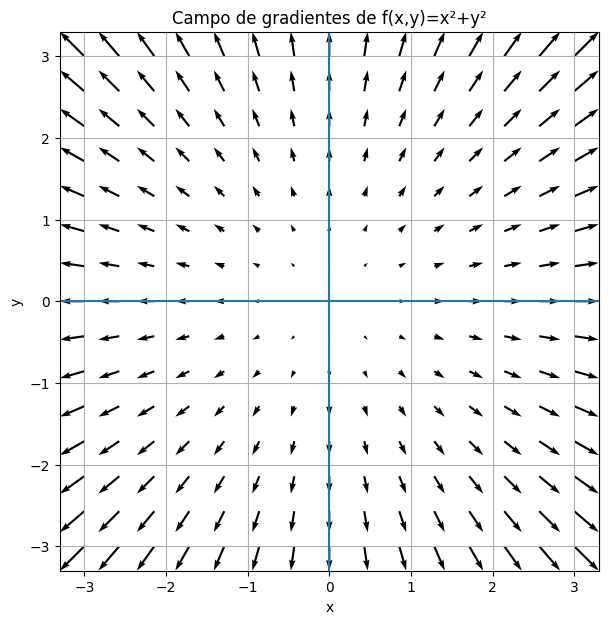

In [15]:
x_vals = np.linspace(-3, 3, 15)
y_vals = np.linspace(-3, 3, 15)

X_grid, Y_grid = np.meshgrid(x_vals, y_vals)

U = 2 * X_grid
V = 2 * Y_grid

plt.figure(figsize=(7, 7))
plt.quiver(X_grid, Y_grid, U, V)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Campo de gradientes de f(x,y)=x²+y²")
plt.axhline(0)
plt.axvline(0)
plt.grid(True)
plt.gca().set_aspect("equal", adjustable="box")
plt.show()

## Descida do Gradiente em Duas Dimensões

Para minimizar uma função de várias variáveis, utiliza-se o gradiente para atualizar os parâmetros. Exemplo:

$$
\mathbf{w} \leftarrow \mathbf{w} - \alpha \nabla f(\mathbf{w})
$$

No caso de $f(x,y)=x^2+y^2$, o mínimo está em $(0,0)$.

In [16]:
def descida_gradiente_2d(ponto_inicial, alpha=0.1, passos=30):
    ponto = np.array(ponto_inicial, dtype=float)
    historico = [ponto.copy()]

    for _ in range(passos):
        grad = grad_f2(ponto[0], ponto[1])
        ponto = ponto - alpha * grad
        historico.append(ponto.copy())

    return np.array(historico)

historico = descida_gradiente_2d([3, 2], alpha=0.1, passos=30)

print("Ponto final:", historico[-1])

Ponto final: [0.0037 0.0025]


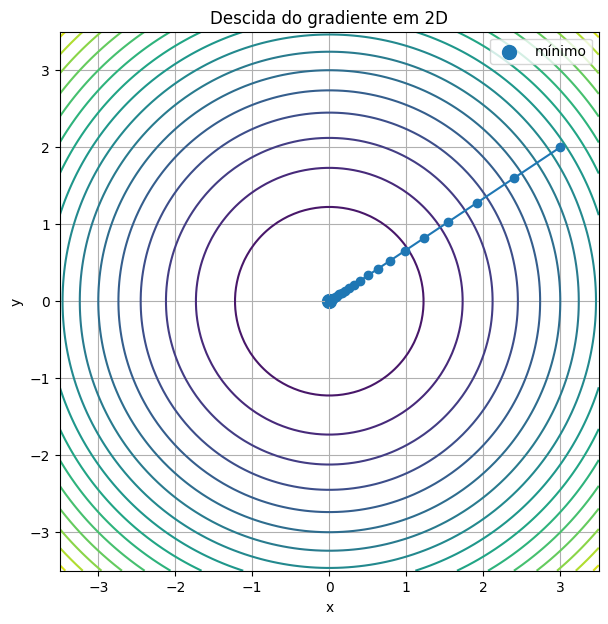

In [17]:
plt.figure(figsize=(7, 7))

contornos_x = np.linspace(-3.5, 3.5, 100)
contornos_y = np.linspace(-3.5, 3.5, 100)
CX, CY = np.meshgrid(contornos_x, contornos_y)
CZ = f2(CX, CY)

plt.contour(CX, CY, CZ, levels=20)
plt.plot(historico[:, 0], historico[:, 1], marker="o")
plt.scatter([0], [0], s=100, label="mínimo")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Descida do gradiente em 2D")
plt.legend()
plt.grid(True)
plt.gca().set_aspect("equal", adjustable="box")
plt.show()

# Regra da Cadeia

Considerando uma função composta:

$$
z = f(g(x))
$$

então:

$$
\frac{dz}{dx}
=
\frac{df}{dg}
\frac{dg}{dx}
$$

Por exemplo, em redes neurais artificiais, uma saída depende de várias operações encadeadas. O algoritmo de **backpropagation** aplica a regra da cadeia para calcular os gradientes.

## Exemplo Simples da Regra da Cadeia

Considerando a função:

$$
y = (3x + 2)^2
$$

Define-se:

$$
u = 3x + 2
$$

e

$$
y = u^2
$$

Pela regra da cadeia:

$$
\frac{dy}{dx}
=
\frac{dy}{du}
\frac{du}{dx}
=
2u \cdot 3
=
6(3x+2)
$$

In [18]:
x_sym = sp.Symbol("x")

y_expr = (3*x_sym + 2)**2

dy_dx = sp.diff(y_expr, x_sym)

print("y =", y_expr)
print("dy/dx =", dy_dx)

y = (3*x + 2)**2
dy/dx = 18*x + 12


## Calculando de Forma Numérica

In [41]:
def y_func(x):
    return (3*x + 2)**2

def dy_dx_exato(x):
    return 6*(3*x + 2)

for valor in [-2, 0, 1, 3]:
    print(
        f"x={valor: .1f}, derivada exata={dy_dx_exato(valor): .4f}, "
        f"derivada numérica={derivada_numerica(y_func, valor): .4f}"
    )

x=-2.0, derivada exata=-24.0000, derivada numérica=-23.9999
x= 0.0, derivada exata= 12.0000, derivada numérica= 12.0001
x= 1.0, derivada exata= 30.0000, derivada numérica= 30.0001
x= 3.0, derivada exata= 66.0000, derivada numérica= 66.0001


# Funções de Ativação e Derivadas

Redes neurais usam funções de ativação para introduzir não linearidade.

Algumas funções comuns:

## Sigmoid

A função sigmoid é:

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

Sua derivada é:

$$
\sigma'(x) = \sigma(x)(1 - \sigma(x))
$$

Ela comprime valores para o intervalo entre 0 e 1.

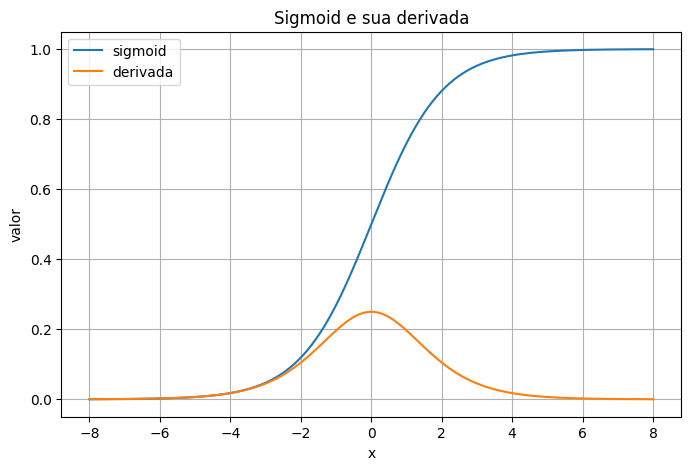

In [20]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def d_sigmoid(x):
    s = sigmoid(x)
    return s * (1 - s)

x = np.linspace(-8, 8, 400)

plt.figure(figsize=(8, 5))
plt.plot(x, sigmoid(x), label="sigmoid")
plt.plot(x, d_sigmoid(x), label="derivada")
plt.xlabel("x")
plt.ylabel("valor")
plt.title("Sigmoid e sua derivada")
plt.legend()
plt.grid(True)
plt.show()

## Tanh

A função tangente hiperbólica é:

$$
\tanh(x)
$$

Sua saída fica entre -1 e 1.

A derivada é:

$$
\frac{d}{dx}\tanh(x) = 1 - \tanh^2(x)
$$

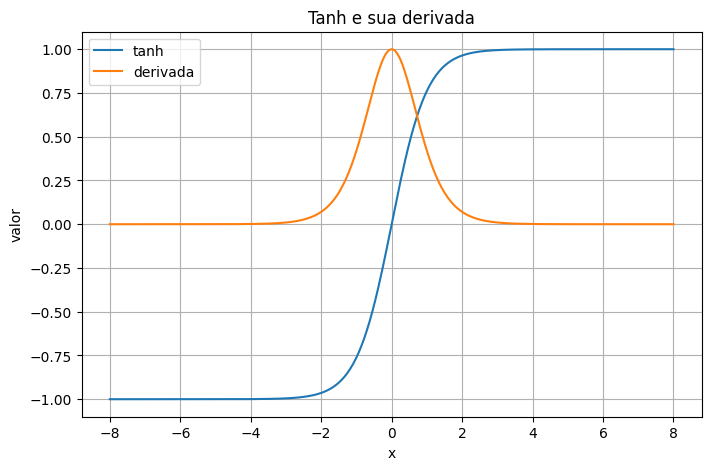

In [21]:
def d_tanh(x):
    return 1 - np.tanh(x)**2

plt.figure(figsize=(8, 5))
plt.plot(x, np.tanh(x), label="tanh")
plt.plot(x, d_tanh(x), label="derivada")
plt.xlabel("x")
plt.ylabel("valor")
plt.title("Tanh e sua derivada")
plt.legend()
plt.grid(True)
plt.show()

## ReLU

A função ReLU é:

$$
ReLU(x) = \max(0,x)
$$

Sua derivada é:

$$
ReLU'(x) =
\begin{cases}
0, & x < 0 \\
1, & x > 0
\end{cases}
$$

No ponto $x=0$, a derivada não é definida. Na prática, bibliotecas de deep learning usam uma convenção.

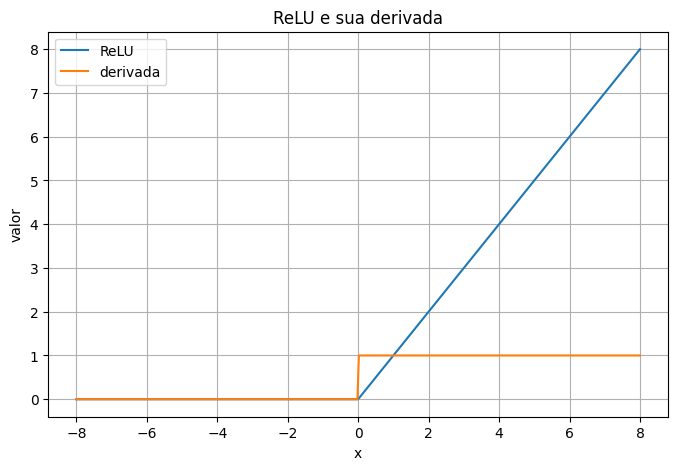

In [22]:
def relu(x):
    return np.maximum(0, x)

def d_relu(x):
    return (x > 0).astype(float)

plt.figure(figsize=(8, 5))
plt.plot(x, relu(x), label="ReLU")
plt.plot(x, d_relu(x), label="derivada")
plt.xlabel("x")
plt.ylabel("valor")
plt.title("ReLU e sua derivada")
plt.legend()
plt.grid(True)
plt.show()

# Função de Perda em Regressão Linear

Um modelo linear é definido na forma:

$$
\hat{y} = wx + b
$$

A função de perda utilizada é o erro quadrático médio, definido da seguinte forma:

$$
L(w,b)
=
\frac{1}{n}
\sum_{i=1}^{n}
(\hat{y}_i - y_i)^2
$$

Substituindo $\hat{y}_i = wx_i + b$:

$$
L(w,b)
=
\frac{1}{n}
\sum_{i=1}^{n}
(wx_i + b - y_i)^2
$$

O objetivo é encontrar $w$ e $b$ que minimizam $L(w,b)$.

## Exemplo com Dados Sintéticos (aleatórios)

Dados aproximadamente lineares.

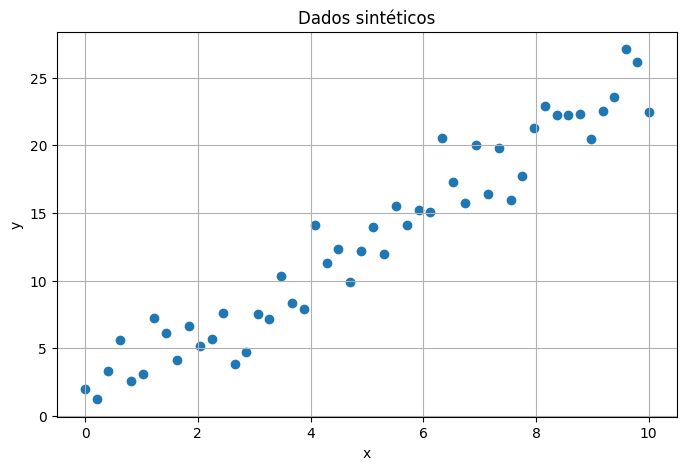

In [23]:
np.random.seed(42)

x_dados = np.linspace(0, 10, 50)
y_dados = 2.5 * x_dados + 1.0 + np.random.normal(0, 2, size=len(x_dados))

plt.figure(figsize=(8, 5))
plt.scatter(x_dados, y_dados)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Dados sintéticos")
plt.grid(True)
plt.show()

## Definindo o Modelo Linear e a Função de Perda

In [24]:
def predizer(x, w, b):
    return w * x + b

def mse(x, y, w, b):
    y_pred = predizer(x, w, b)
    return np.mean((y_pred - y)**2)

print("Perda inicial:", mse(x_dados, y_dados, w=0, b=0))

Perda inicial: 222.874984898052


## Derivadas Parciais da Função de Perda

A função de perda é:

$$
L(w,b)
=
\frac{1}{n}
\sum_{i=1}^{n}
(wx_i + b - y_i)^2
$$

As derivadas parciais são:

$$
\frac{\partial L}{\partial w}
=
\frac{2}{n}
\sum_{i=1}^{n}
(wx_i + b - y_i)x_i
$$

$$
\frac{\partial L}{\partial b}
=
\frac{2}{n}
\sum_{i=1}^{n}
(wx_i + b - y_i)
$$

In [25]:
def gradientes_mse(x, y, w, b):
    n = len(x)
    y_pred = predizer(x, w, b)
    erro = y_pred - y

    dL_dw = (2/n) * np.sum(erro * x)
    dL_db = (2/n) * np.sum(erro)

    return dL_dw, dL_db

print("Gradientes iniciais:")
print(gradientes_mse(x_dados, y_dados, w=0, b=0))

Gradientes iniciais:
(np.float64(-171.84619987169154), np.float64(-26.098104378975442))


## Treinamento de um Modelo de Regressão Linear com a Descida do Gradiente

In [43]:
w = 0.0
b = 0.0
alpha = 0.01
epocas = 1000

historico_perda = []

for epoca in range(epocas):
    dL_dw, dL_db = gradientes_mse(x_dados, y_dados, w, b)

    w = w - alpha * dL_dw
    b = b - alpha * dL_db

    perda = mse(x_dados, y_dados, w, b)
    historico_perda.append(perda)

print("w aprendido:", w)
print("b aprendido:", b)
print("perda final:", historico_perda[-1])

w aprendido: 2.384755780111989
b aprendido: 1.1240562502474123
perda final: 3.300573190224381


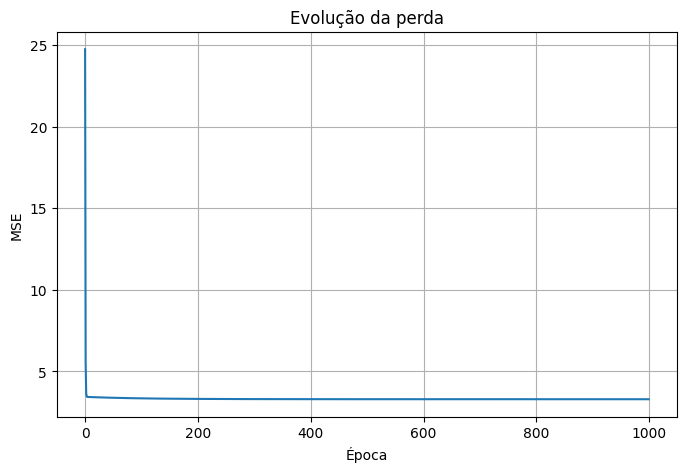

In [44]:
plt.figure(figsize=(8, 5))
plt.plot(historico_perda)
plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Evolução da perda")
plt.grid(True)
plt.show()

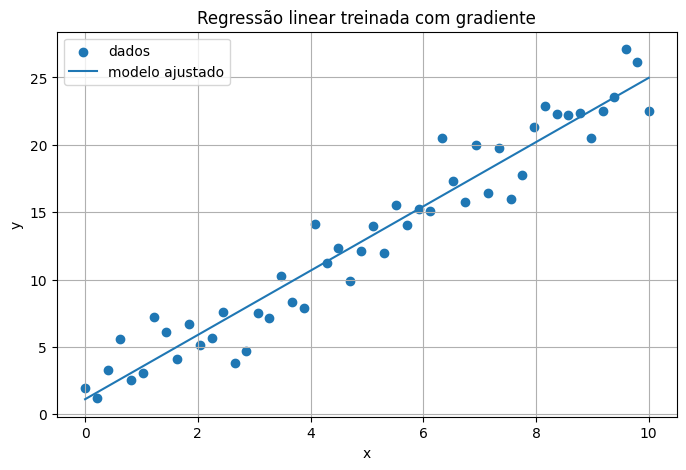

In [45]:
y_pred = predizer(x_dados, w, b)

plt.figure(figsize=(8, 5))
plt.scatter(x_dados, y_dados, label="dados")
plt.plot(x_dados, y_pred, label="modelo ajustado")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Regressão linear treinada com gradiente")
plt.legend()
plt.grid(True)
plt.show()

# Superfície da Função de Perda

Como a perda depende de dois parâmetros, $w$ e $b$, é possível visualizar sua superfície.

Isso ajuda a entender o que significa minimizar uma função.

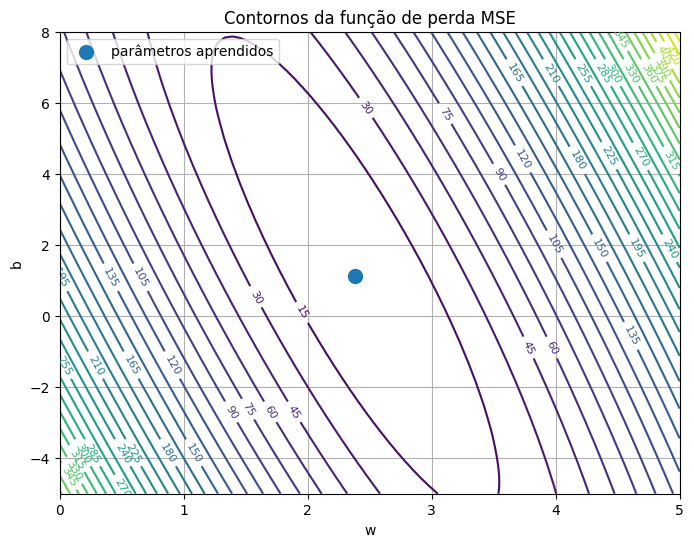

In [29]:
w_vals = np.linspace(0, 5, 80)
b_vals = np.linspace(-5, 8, 80)

W, B = np.meshgrid(w_vals, b_vals)
Z = np.zeros_like(W)

for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        Z[i, j] = mse(x_dados, y_dados, W[i, j], B[i, j])

plt.figure(figsize=(8, 6))
contour = plt.contour(W, B, Z, levels=30)
plt.clabel(contour, inline=True, fontsize=8)
plt.scatter([w], [b], s=100, label="parâmetros aprendidos")
plt.xlabel("w")
plt.ylabel("b")
plt.title("Contornos da função de perda MSE")
plt.legend()
plt.grid(True)
plt.show()

# Gradiente Numérico versus Gradiente Analítico

Em aprendizado de máquina, é possível calcular gradientes de duas maneiras:

1. **Analiticamente**, usando fórmulas de derivadas.
2. **Numericamente**, usando aproximações por diferenças finitas.

O gradiente numérico é útil para testar se a implementação do gradiente analítico está correta.

## Gradiente Numérico para a Função MSE

In [30]:
def gradiente_numerico_mse(x, y, w, b, h=1e-5):
    dL_dw = (mse(x, y, w + h, b) - mse(x, y, w, b)) / h
    dL_db = (mse(x, y, w, b + h) - mse(x, y, w, b)) / h

    return dL_dw, dL_db

w_teste = 1.5
b_teste = 0.5

grad_analitico = gradientes_mse(x_dados, y_dados, w_teste, b_teste)
grad_numerico = gradiente_numerico_mse(x_dados, y_dados, w_teste, b_teste)

print("Gradiente analítico:", grad_analitico)
print("Gradiente numérico:", grad_numerico)

Gradiente analítico: (np.float64(-65.82579170842621), np.float64(-10.09810437897544))
Gradiente numérico: (np.float64(-65.82545497337833), np.float64(-10.098094379173972))


# Backpropagation em uma Rede Neural Artificial Simples

Considerando:

$$
\hat{y} = wx + b
$$

com perda:

$$
L = (\hat{y} - y)^2
$$

Esse exemplo já mostra a estrutura da regra da cadeia.

Temos:

$$
\hat{y} = wx + b
$$

$$
L = (\hat{y} - y)^2
$$

Pela regra da cadeia:

$$
\frac{\partial L}{\partial w}
=
\frac{\partial L}{\partial \hat{y}}
\frac{\partial \hat{y}}{\partial w}
$$

Como:

$$
\frac{\partial L}{\partial \hat{y}} = 2(\hat{y}-y)
$$

e

$$
\frac{\partial \hat{y}}{\partial w} = x
$$

então:

$$
\frac{\partial L}{\partial w}
=
2(\hat{y}-y)x
$$

In [31]:
x_ex = 2.0
y_ex = 5.0
w_ex = 1.0
b_ex = 0.0

y_hat = w_ex * x_ex + b_ex
L_ex = (y_hat - y_ex)**2

dL_dyhat = 2 * (y_hat - y_ex)
dyhat_dw = x_ex
dyhat_db = 1

dL_dw = dL_dyhat * dyhat_dw
dL_db = dL_dyhat * dyhat_db

print("y_hat:", y_hat)
print("L:", L_ex)
print("dL/dy_hat:", dL_dyhat)
print("dL/dw:", dL_dw)
print("dL/db:", dL_db)

y_hat: 2.0
L: 9.0
dL/dy_hat: -6.0
dL/dw: -12.0
dL/db: -6.0


## Rede Neural com Ativação Sigmoid

Agora considere:

$$
z = wx + b
$$

$$
a = \sigma(z)
$$

$$
L = (a - y)^2
$$

Pela regra da cadeia:

$$
\frac{\partial L}{\partial w}
=
\frac{\partial L}{\partial a}
\frac{\partial a}{\partial z}
\frac{\partial z}{\partial w}
$$

Esse encadeamento é a ideia central do backpropagation.

In [32]:
x_ex = 1.5
y_ex = 1.0
w_ex = 0.8
b_ex = -0.2

z = w_ex * x_ex + b_ex
a = sigmoid(z)
L_ex = (a - y_ex)**2

dL_da = 2 * (a - y_ex)
da_dz = a * (1 - a)
dz_dw = x_ex
dz_db = 1

dL_dw = dL_da * da_dz * dz_dw
dL_db = dL_da * da_dz * dz_db

print("z:", z)
print("a:", a)
print("L:", L_ex)
print("dL/dw:", dL_dw)
print("dL/db:", dL_db)

z: 1.0000000000000002
a: 0.7310585786300049
L: 0.07232948812851325
dL/dw: -0.15863127835280014
dL/db: -0.10575418556853343


# Mínimos, Máximos e Pontos Críticos

Um ponto crítico ocorre quando a derivada é zero ou não existe.

Para funções de uma variável:

$$
f'(x)=0
$$

pode indicar:

- mínimo local;
- máximo local;
- ponto de inflexão.

Exemplo:

$$
f(x) = x^2
$$

tem mínimo em $x=0$.

Já:

$$
f(x) = -x^2
$$

tem máximo em $x=0$.

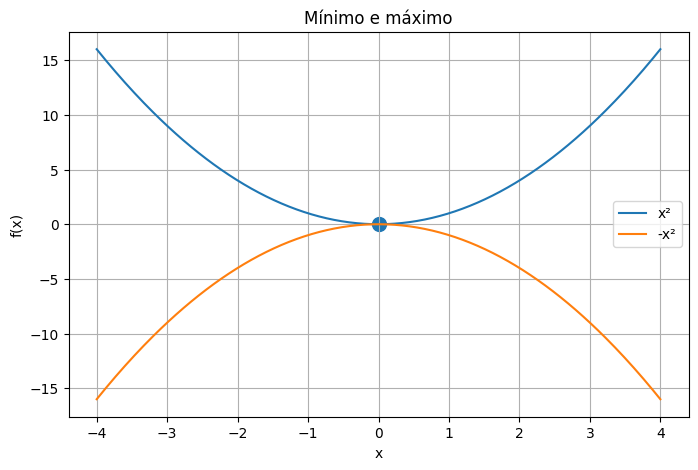

In [34]:
x = np.linspace(-4, 4, 300)

plt.figure(figsize=(8, 5))
plt.plot(x, x**2, label="x²")
plt.plot(x, -x**2, label="-x²")
plt.scatter([0], [0], s=100)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Mínimo e máximo")
plt.legend()
plt.grid(True)
plt.show()

## Funções não convexas

Em redes neurais profundas, a função de perda pode ser muito complexa e não convexa.

Isso significa que ela pode ter:

- vários mínimos locais;
- regiões planas;
- pontos de sela;
- vales estreitos;
- regiões de forte curvatura.

Mesmo assim, métodos baseados em gradiente funcionam muito bem na prática em muitos problemas.

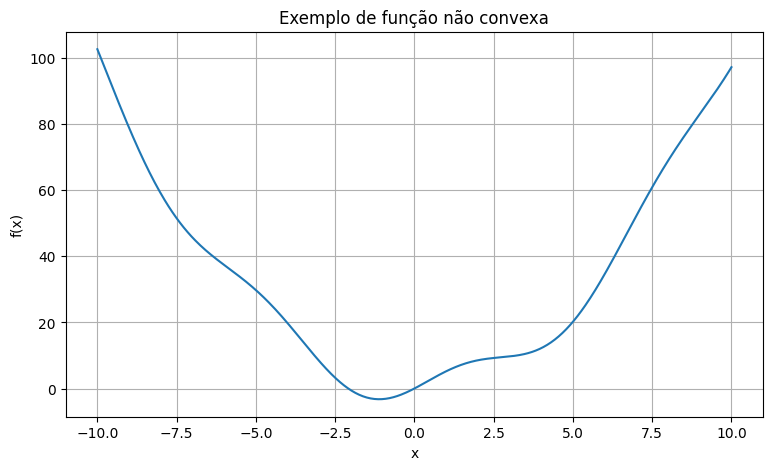

In [35]:
def funcao_nao_convexa(x):
    return x**2 + 5*np.sin(x)

def d_funcao_nao_convexa(x):
    return 2*x + 5*np.cos(x)

x = np.linspace(-10, 10, 500)

plt.figure(figsize=(9, 5))
plt.plot(x, funcao_nao_convexa(x))
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Exemplo de função não convexa")
plt.grid(True)
plt.show()

## Descida do Gradiente em Função não Convexa

O ponto final pode depender do ponto inicial.

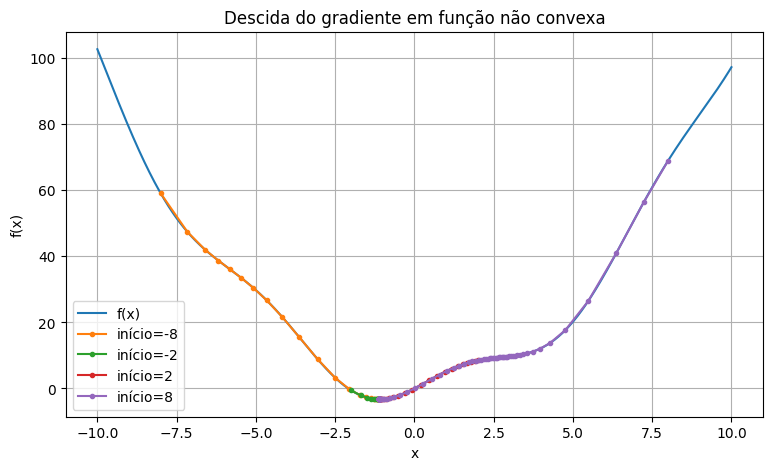

In [36]:
def descida_1d(func_derivada, x_inicial, alpha=0.05, passos=100):
    x_atual = x_inicial
    historico = [x_atual]

    for _ in range(passos):
        x_atual = x_atual - alpha * func_derivada(x_atual)
        historico.append(x_atual)

    return np.array(historico)

inicios = [-8, -2, 2, 8]

plt.figure(figsize=(9, 5))
plt.plot(x, funcao_nao_convexa(x), label="f(x)")

for inicio in inicios:
    hist = descida_1d(d_funcao_nao_convexa, inicio, alpha=0.05, passos=80)
    plt.plot(hist, funcao_nao_convexa(hist), marker="o", markersize=3, label=f"início={inicio}")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Descida do gradiente em função não convexa")
plt.legend()
plt.grid(True)
plt.show()

# Derivadas Parciais com mais de dois Parâmetros

Um modelo real pode ter milhares, milhões ou bilhões de parâmetros.

Se a função de perda depende de muitos parâmetros:

$$
L(w_1, w_2, ..., w_n)
$$

o gradiente é:

$$
\nabla L =
\begin{bmatrix}
\frac{\partial L}{\partial w_1} \\
\frac{\partial L}{\partial w_2} \\
\vdots \\
\frac{\partial L}{\partial w_n}
\end{bmatrix}
$$

Cada componente indica como a perda muda quando um parâmetro muda um pouco.

## Exemplo com Três Variáveis

Considere:

$$
f(x,y,z) = x^2 + 2y^2 + 3z^2
$$

O gradiente é:

$$
\nabla f =
\begin{bmatrix}
2x \\
4y \\
6z
\end{bmatrix}
$$

In [37]:
x_sym, y_sym, z_sym = sp.symbols("x y z")

f_xyz = x_sym**2 + 2*y_sym**2 + 3*z_sym**2

grad_xyz = [
    sp.diff(f_xyz, x_sym),
    sp.diff(f_xyz, y_sym),
    sp.diff(f_xyz, z_sym)
]

print("f(x,y,z) =", f_xyz)
print("Gradiente:", grad_xyz)

f(x,y,z) = x**2 + 2*y**2 + 3*z**2
Gradiente: [2*x, 4*y, 6*z]


# Interpretação Prática do Gradiente

Durante o treinamento de um modelo:

- o modelo faz uma predição;
- a função de perda mede o erro;
- os gradientes indicam como alterar os parâmetros;
- o otimizador atualiza os parâmetros;
- o processo se repete por várias épocas.

Fluxo simplificado:

```text
dados -> modelo -> predição -> perda -> gradientes -> atualização dos parâmetros
```

## Exemplo: treinando um modelo simples

In [46]:
# Dados
x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([3, 5, 7, 9, 11], dtype=float)  # aproximadamente y = 2x + 1

# Parâmetros
w = 0.0
b = 0.0
alpha = 0.01

for epoca in range(500):
    y_hat = w * x + b
    erro = y_hat - y

    loss = np.mean(erro**2)

    dL_dw = 2 * np.mean(erro * x)
    dL_db = 2 * np.mean(erro)

    w -= alpha * dL_dw
    b -= alpha * dL_db

print("w:", w)
print("b:", b)
print("loss:", loss)

w: 2.02110121171202
b: 0.9238179303413873
loss: 0.0010635558739857135
